# Iris Flower Classification

## OIBSIP Data Science Internship - Task 1

### Objective
Build a machine learning classification model to identify the species of an iris flower as Setosa, Versicolor, or Virginica using its physical measurements.

### Technologies Used
- Python
- Pandas
- Scikit-learn
- Matplotlib
- Seaborn
- Jupyter Notebook


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

In [18]:
# Load the Iris dataset
iris = load_iris(as_frame=True)

# Create a copy of the dataset
df = iris.frame.copy()

# Display the first five rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [19]:
# Convert target numbers into species names
df["species"] = df["target"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

# Remove the numeric target column
df.drop("target", axis=1, inplace=True)

# Display the first five rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the structure, data types, missing values, and statistical properties of the dataset.

In [21]:
# Check the number of rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (150, 5)


In [22]:
# Check data types of all columns
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object

In [23]:
# Check for missing values
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

In [24]:
# Display descriptive statistics
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Data Visualization

Visualizations help us understand the distribution of the features and how well the iris species can be separated.

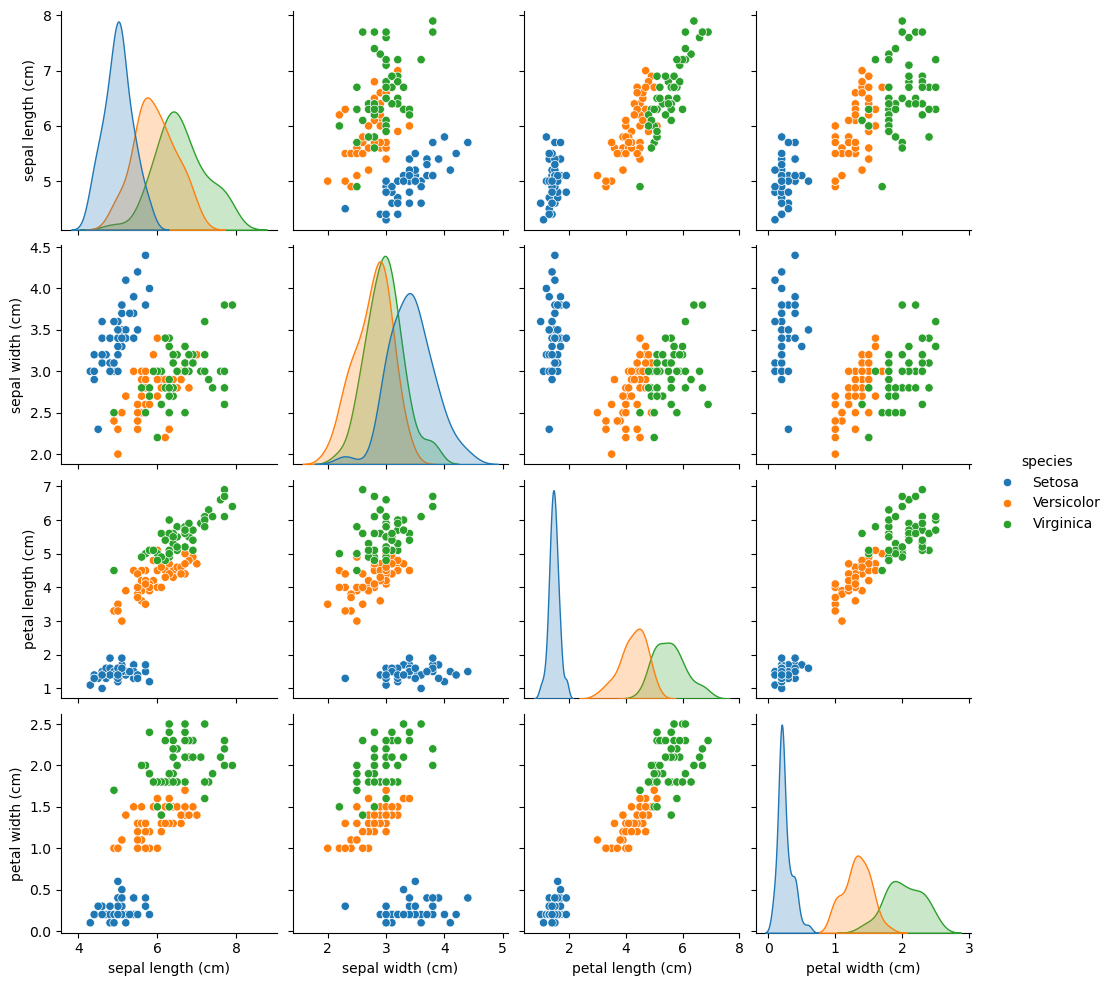

In [26]:
# Pairplot showing relationships between features by species
sns.pairplot(df, hue="species")
plt.show()

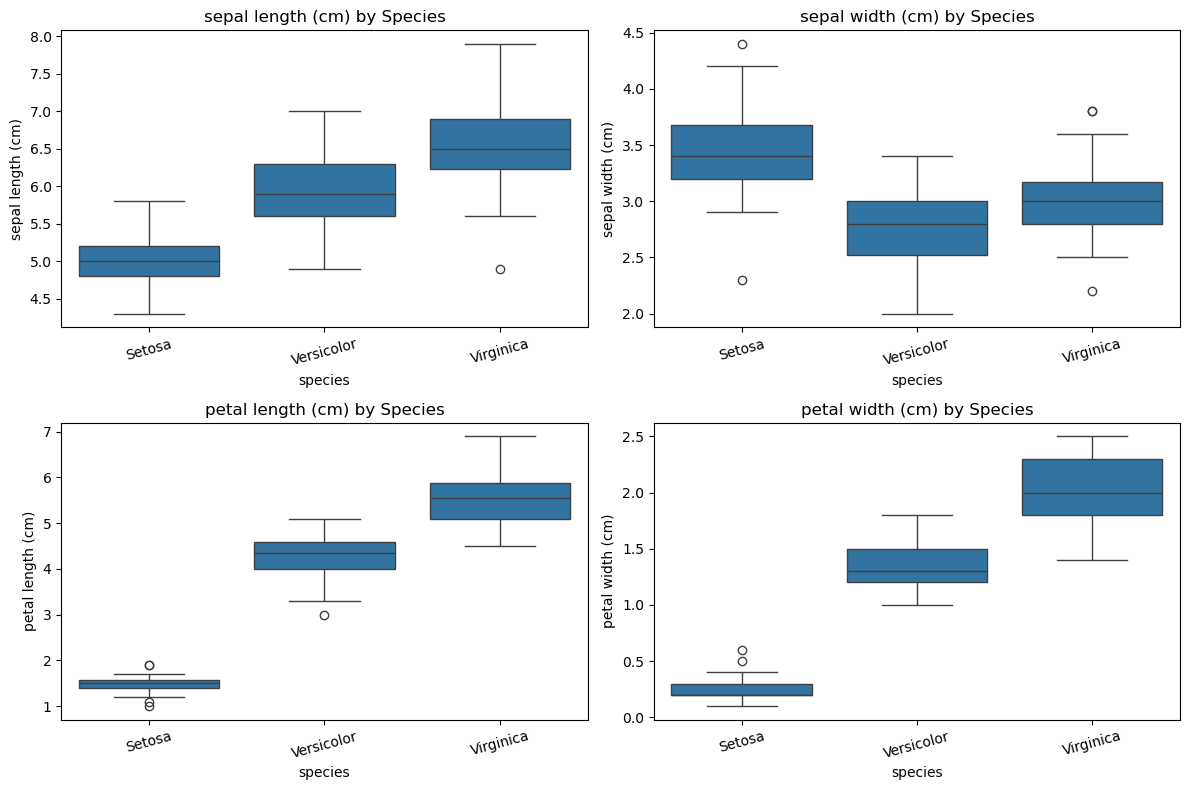

In [27]:
# Create box plots for each numerical feature
features = iris.feature_names

plt.figure(figsize=(12, 8))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x="species", y=feature)
    plt.title(f"{feature} by Species")
    plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

## Feature Selection Discussion

From the visualizations, petal length and petal width show strong differences among the three iris species and appear to be the most discriminative features. Sepal measurements show more overlap between some species.

Therefore, petal length and petal width are particularly useful features for distinguishing the iris species.

## Train-Test Split

The dataset is divided into training and testing sets. The model learns from the training data and is evaluated on unseen test data.

In [31]:
from sklearn.model_selection import train_test_split

# Features and target
X = df[iris.feature_names]
y = iris.target

# Split the dataset into 80% training and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [33]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression pipeline
logistic_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=200)
)

# Train the model
logistic_model.fit(X_train, y_train)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test)

print("Logistic Regression predictions:")
print(y_pred_logistic)

Logistic Regression predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]


In [35]:
from sklearn.neighbors import KNeighborsClassifier

# Create KNN pipeline
knn_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=5)
)

# Train the model
knn_model.fit(X_train, y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test)

print("KNN predictions:")
print(y_pred_knn)

KNN predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 1 1 0 2 0]


In [37]:
from sklearn.metrics import accuracy_score

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("Logistic Regression Accuracy:", logistic_accuracy)
print("KNN Accuracy:", knn_accuracy)

Logistic Regression Accuracy: 0.9333333333333333
KNN Accuracy: 0.9333333333333333


In [39]:
from sklearn.metrics import classification_report

print("Logistic Regression Classification Report")
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=iris.target_names
    )
)

Logistic Regression Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [41]:
print("KNN Classification Report")
print(
    classification_report(
        y_test,
        y_pred_knn,
        target_names=iris.target_names
    )
)

KNN Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



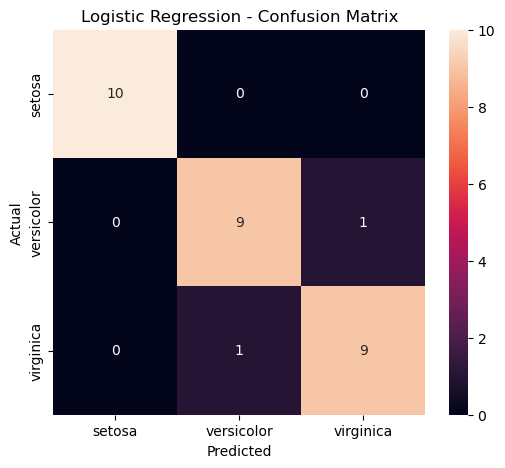

In [43]:
from sklearn.metrics import confusion_matrix

cm_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

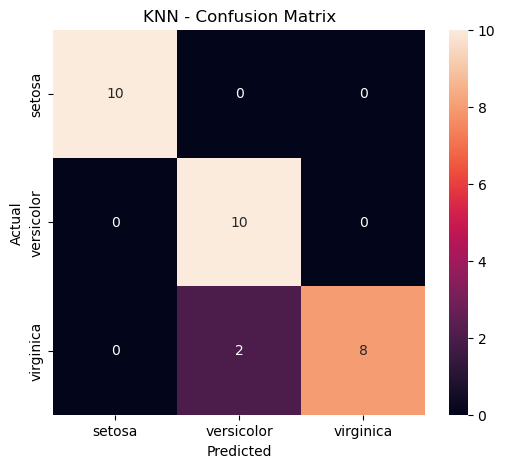

In [45]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN - Confusion Matrix")
plt.show()

In [47]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "K-Nearest Neighbours"],
    "Accuracy": [logistic_accuracy, knn_accuracy]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.933333
1,K-Nearest Neighbours,0.933333


In [49]:
best_model = comparison.loc[
    comparison["Accuracy"].idxmax()
]

print("Best Performing Model:", best_model["Model"])
print("Best Accuracy:", best_model["Accuracy"])

Best Performing Model: Logistic Regression
Best Accuracy: 0.9333333333333333


## Conclusion

Two classification models, Logistic Regression and K-Nearest Neighbours, were trained and evaluated on the Iris dataset.

The models were compared using accuracy, precision, recall, F1-score, and confusion matrices.

Based on the evaluation results, the model with the highest test accuracy is considered the best-performing model for this task.

The visualizations also showed that petal length and petal width are particularly discriminative features for distinguishing the three iris species.